In [4]:
import torch
import numpy as np
from face_score import FACEScorer
from fft_utils import FFTProcessor
from scipy.fft import fft

In [5]:
fft_processor = FFTProcessor()

In [6]:
face_scorer = FACEScorer(model_path='/Users/xy/models/gpt2-xl',
                         device='mps')

/Users/xy/.pyenv/versions/miniconda3-latest/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
s1 = '请给我一杯水'

nll1 = face_scorer.texts_to_nll([s1])
print(nll1)
print('nll1 length:', len(nll1[0]))

ids1 = face_scorer.tokenizer.encode(s1)
print('ids1 length:', len(ids1))

  0%|          | 0/1 [00:00<?, ?it/s]/Users/xy/.pyenv/versions/miniconda3-latest/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2855: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
100%|██████████| 1/1 [00:04<00:00,  4.60s/it]


[tensor([1.9267, 3.4741, 2.5729, 1.5222, 1.8072, 0.0494, 4.6574, 3.7580, 4.7697,
        5.5095, 1.4289], device='mps:0')]
nll1 length: 11
ids1 length: 12


In [8]:
s1_ch1_nll = torch.sum(nll1[0][0:1])
s1_ch2_nll = torch.sum(nll1[0][1:4])
s1_ch3_nll = torch.sum(nll1[0][4:6])
s1_ch4_nll = torch.sum(nll1[0][6:7])
s1_ch5_nll = torch.sum(nll1[0][7:9])
s1_ch6_nll = torch.sum(nll1[0][9:11])

print(f'{s1_ch1_nll.item():.4f} {s1_ch2_nll.item():.4f} {s1_ch3_nll.item():.4f} {s1_ch4_nll.item():.4f} {s1_ch5_nll.item():.4f} {s1_ch6_nll.item():.4f}')

1.9267 7.5692 1.8566 4.6574 8.5278 6.9384


In [9]:
x1 = [s1_ch1_nll.item(), s1_ch2_nll.item(), s1_ch3_nll.item(), s1_ch4_nll.item(), s1_ch5_nll.item(), s1_ch6_nll.item()]
x1 = torch.tensor(x1)

X1_raw = fft(x1)
print(X1_raw)

X1_norm = face_scorer.nll_to_spectrum([x1])
print(X1_norm)

[31.476124 -0.j        -0.6690984+5.2310266j -5.8618693-6.3237314j
 -6.8539505-0.j        -5.8618693+6.3237314j -0.6690984-5.2310266j]
([array([31.476124,  5.273645,  8.622707], dtype=float32)], [array([0.        , 0.16666667, 0.33333333])])


In [10]:
s2 = '请给我一杯茶'

nll2 = face_scorer.texts_to_nll([s2])
print(nll2)
print('nll2 length:', len(nll2[0]))

ids2 = face_scorer.tokenizer.encode(s2)
print('ids2 length:', len(ids2))

100%|██████████| 1/1 [00:00<00:00,  1.65it/s]

[tensor([1.9267, 3.4741, 2.5729, 1.5222, 1.8072, 0.0494, 4.6574, 3.7580, 4.7697,
        3.1793, 4.7093, 2.2368], device='mps:0')]
nll2 length: 12
ids2 length: 13


In [11]:
s2_ch1_nll = torch.sum(nll2[0][0:1])
s2_ch2_nll = torch.sum(nll2[0][1:4])
s2_ch3_nll = torch.sum(nll2[0][4:6])
s2_ch4_nll = torch.sum(nll2[0][6:7])
s2_ch5_nll = torch.sum(nll2[0][7:9])
s2_ch6_nll = torch.sum(nll2[0][9:12])

print(f'{s2_ch1_nll.item():.4f} {s2_ch2_nll.item():.4f} {s2_ch3_nll.item():.4f} {s2_ch4_nll.item():.4f} {s2_ch5_nll.item():.4f} {s2_ch6_nll.item():.4f}')

1.9267 7.5692 1.8566 4.6574 8.5278 10.1254


In [12]:
x2 = [s2_ch1_nll.item(), s2_ch2_nll.item(), s2_ch3_nll.item(), s2_ch4_nll.item(), s2_ch5_nll.item(), s2_ch6_nll.item()]
x2 = torch.tensor(x2)

X2_raw = fft(x2)
print(X2_raw)
X2_norm = face_scorer.nll_to_spectrum([x2])
print(X2_norm)

[ 34.663166 -0.j          0.9244201+7.99109j    -7.455387 -3.5636675j
 -10.040988 -0.j         -7.455387 +3.5636675j   0.9244201-7.99109j  ]
([array([34.663166,  8.044381,  8.263325], dtype=float32)], [array([0.        , 0.16666667, 0.33333333])])


In [13]:
import matplotlib.pyplot as plt

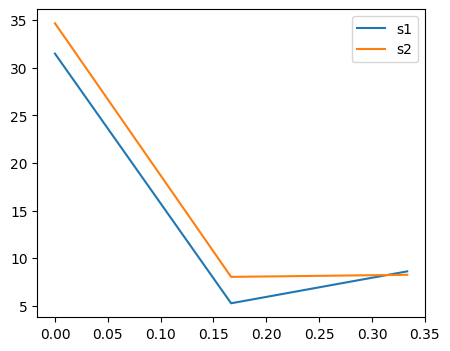

In [45]:
fig, ax = plt.subplots(figsize=(5,4))

x = X1_norm[1][0].tolist()
y1 = X1_norm[0][0].tolist()
y2 = X2_norm[0][0].tolist()

ax.plot(x, y1, label='s1')
ax.plot(x, y2, label='s2')
ax.legend()
# plt.show()
plt.savefig('spectrum.svg')

In [38]:
# Experiment with repetition in time domain
n_repeats = 10

x1_rep = torch.tile(x1, (n_repeats,))
X1_norm_rep = face_scorer.nll_to_spectrum([x1_rep])

x2_rep = torch.tile(x2, (n_repeats,))
X2_norm_rep = face_scorer.nll_to_spectrum([x2_rep])
# print(X2_norm_rep)

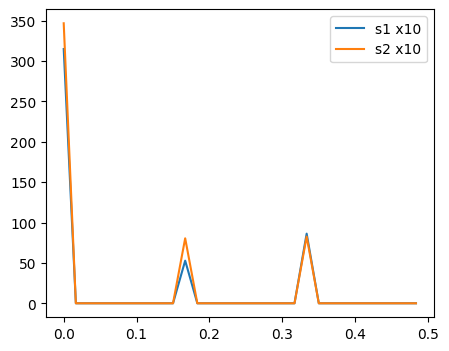

In [46]:
fig, ax = plt.subplots(figsize=(5,4))
x = X2_norm_rep[1][0].tolist()
y1 = X1_norm_rep[0][0].tolist()
y2 = X2_norm_rep[0][0].tolist()

ax.plot(x, y1, label='s1 x10')
ax.plot(x, y2, label='s2 x10')

ax.legend()
# plt.show()
plt.savefig('spectrum_rep.svg')